#**EEG-Based Sleep Stage Classification Using Machine Learning Techniques**  
**Course**: TSAC - Time Series Analysis and Classification (2024/2025)  

**Team Leader:** EDDALIA Wissal  

**Team Members:**      
- HADJAR Lyes  
- EDDALIA Wissal  
- ABID Sara  
- ZANON Nada

**Supervisors:**

- Dr. MEDKOUR Tarek  
- Dr. BERAIRI Houssem    


**Submission Date:** May 17th, 2025

# 1. Introduction

**Overview of the Problem:**  *Classifying Sleep Stages from EEG Data*    

This project addresses the challenge of automatically classifying human sleep stages using electroencephalogram (EEG) recordings. Sleep is a dynamic process consisting of distinct neurophysiological states - wakefulness, three stages of Non-Rapid Eye Movement (NREM) sleep (E1, E2, E3), and Rapid Eye Movement (REM) sleep. Each of these stages exhibits characteristic EEG patterns that serve as the foundation for our classification task.
The dataset provided contains 5000 training samples and 1000 test samples of EEG recordings, with the goal of developing an accurate classification model that can distinguish between these five crucial sleep states. This represents a complex time series classification problem, requiring sophisticated signal processing and machine learning techniques to capture the subtle temporal patterns that differentiate each sleep stage.

**Importance of Sleep Cycle Analysis in Medicine and Neuroscience** :  

Sleep cycle analysis is crucial in medicine and neuroscience, serving as a diagnostic tool for sleep disorders, an early biomarker for neurodegenerative diseases, and a window into psychiatric conditions. It enhances our understanding of circadian rhythms while enabling consumer health applications through wearable technology. Automating sleep stage classification facilitates large-scale studies and personalized interventions that would be impossible with traditional manual scoring, ultimately advancing both clinical care and scientific research across multiple disciplines

***Our Team's Approach to the Challenge***  

1.Feature Engineering:  

2.Multi-stage Classification:  

3.Validation Strategy:  




Throughout this notebook, we document our systematic exploration of the problem space, from initial data analysis through feature extraction, model selection, hyperparameter tuning, and final evaluation. Our goal is to develop not just an accurate classifier, but one that advances understanding of sleep neurophysiology and supports clinical applications.

# 2. Data Understanding


#### **loading the data**

In [ ]:
%pip install antropy

In [ ]:
%pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.8 MB/s eta 0:00:00


**import libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.stats import skew, kurtosis, entropy
import pywt
import antropy as ant
import tensorflow as tf

import seaborn as sns
from scipy.signal import welch, butter, sosfiltfilt


# Machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.pipeline import Pipeline


# For hyperparameter tuning
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plotting settings
plt.style.use('ggplot')
sns.set(style="whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_data = pd.read_csv("/content/train.csv", header=None)
test_data = pd.read_csv("/content/test.csv", header=None)


#dividing into label and timeseries
X_train = train_data.iloc[: , 1:].values
y_train = train_data.iloc[:, 0].values

X_test = test_data

print("X train shape: ", X_train.shape)
print("y train shape: ", y_train.shape)
print("X test shape: ", X_test.shape)
print("The classes in this dataset: ", np.unique(y_train))

X train shape:  (4999, 178)
y train shape:  (4999,)
X test shape:  (1000, 178)
The classes in this dataset:  [0 1 2 3 4]


* Each row is one signal instance
* The first column in the train data is the class label
* Usually sleep scoring system divide the recording of EEG into 30 seconds intervals called epochs.


#### **Visualizing the distribution of the classes**

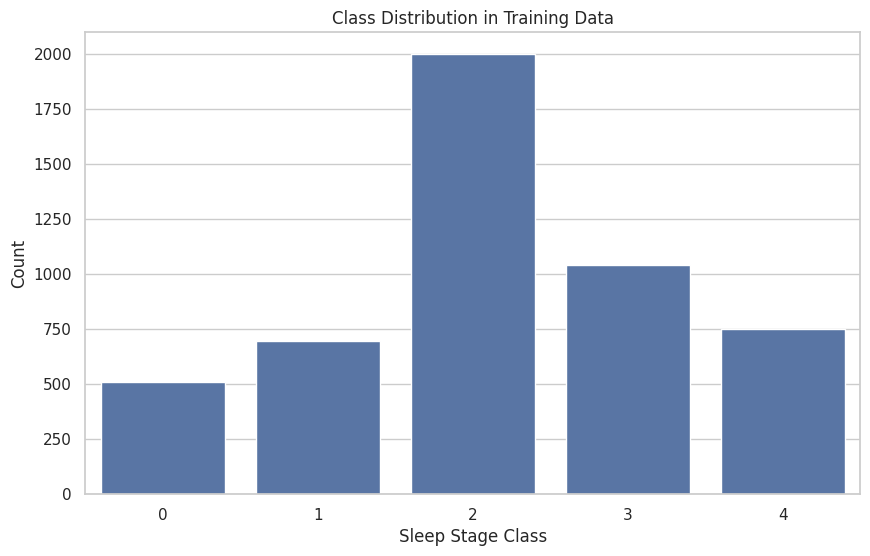

In [ ]:
class_counts = pd.Series(y_train).value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution in Training Data')
plt.xlabel('Sleep Stage Class')
plt.ylabel('Count')
plt.show()

The classes appear to be normally distributed



| Label  | Scientific Term        | Key EEG Features                                                     |
| ----------- | ---------------------- | -------------------------------------------------------------------- |
| **Wake**    | Wakefulness            | High alpha and beta power, low delta.                                |
| **E1 (N1)** | Light sleep stage 1    | Theta power rises, alpha reduces.                                    |
| **E2 (N2)** | Light sleep stage 2    | Theta + sleep spindles (sigma).                                      |
| **E3 (N3)** | Deep sleep (slow-wave) | Dominated by delta power.                                            |
| **REM**     | Dream sleep            | Mixed frequency (theta, some beta), low muscle tone, resembles wake. |


### **Visualizing signals from each class**

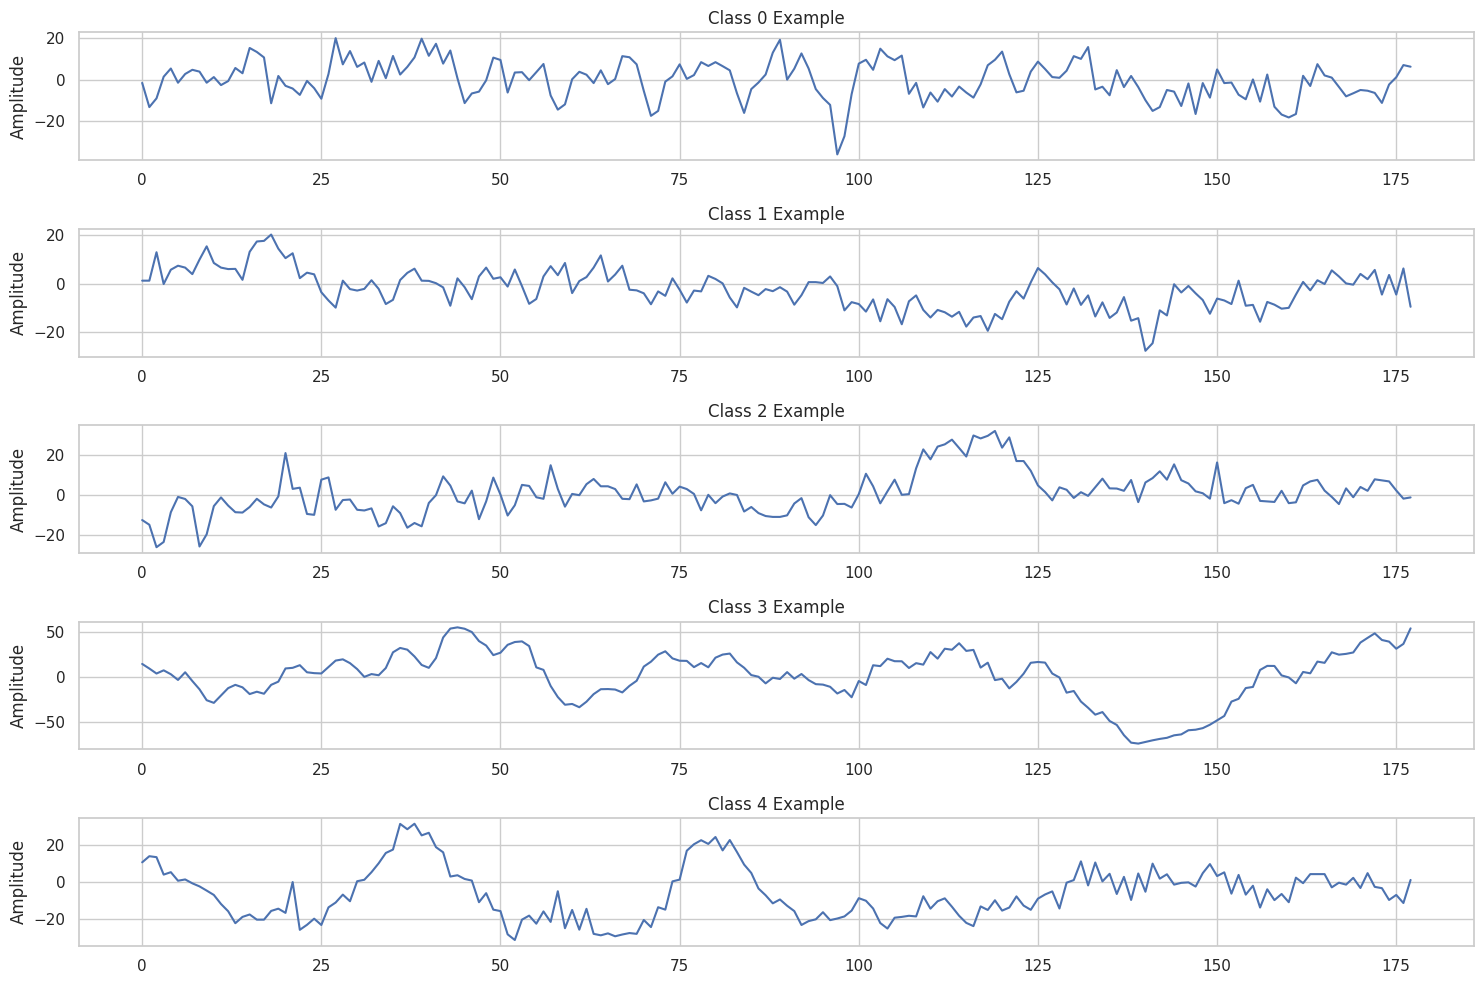

In [ ]:
# Plot example signals from each class
classes = np.unique(y_train)
plt.figure(figsize=(15, 10))

for i, c in enumerate(classes):
    class_idx = np.where(y_train == c)[0][0]
    plt.subplot(len(classes), 1, i+1)
    plt.plot(X_train[class_idx])
    plt.title(f'Class {c} Example')
    plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [ ]:
X_train = pd.DataFrame(X_train)
print("Training set: ")
X_train.head()

Training set: 


,0,1,2,3,4,5,6,7,8,9,...,168,169,170,171,172,173,174,175,176,177
0,-1.608303,-13.170696,-8.997802,1.347497,5.259585,-1.521367,2.651526,4.651038,3.781685,-1.521367,...,-8.041514,-6.563614,-4.998779,-5.346520,-6.389744,-11.171185,-2.390720,1.086691,6.911355,6.128938
1,-2.825397,2.390720,3.955555,-4.216361,2.477656,2.129914,3.955555,-5.172649,5.694261,1.608303,...,4.129426,7.085226,-2.390720,-2.303785,-3.694750,4.564103,-6.215873,-2.738462,-4.477167,-4.390232
2,-15.952625,-3.347008,-15.517949,-9.432479,-16.474237,-6.650549,-14.909402,-12.214408,-10.823443,-7.259097,...,-4.390232,-0.738950,4.477167,12.996825,21.951160,21.081806,21.603418,14.909402,9.345543,6.998291
3,-26.558731,-18.560684,-12.040537,-4.216361,-9.432479,1.260562,-2.216850,-3.520879,-5.781197,-6.128938,...,-3.086203,-0.652015,3.607814,15.170208,16.039560,6.128938,3.955555,-1.956044,-2.390720,-4.651038
4,-5.607326,6.042003,-4.129426,-5.172649,-7.172161,-11.953602,-7.780708,-0.130403,-2.912332,-4.390232,...,-1.260562,1.608303,4.564103,-4.911844,10.301831,10.127961,8.389256,-2.216850,-4.390232,0.478144


In [ ]:
X_test = pd.DataFrame(X_test)
print("Test set: ")
X_test.head()

Test set: 


,0,1,2,3,4,5,6,7,8,9,...,168,169,170,171,172,173,174,175,176,177
0,3.433944,20.734066,15.517949,10.301831,2.042979,-0.043468,-13.431501,-10.649572,11.431991,5.694261,...,-1.869109,7.172161,1.434432,4.651038,-5.520391,6.824420,-11.866667,15.257143,4.129426,10.910378
1,6.650549,5.346520,-0.043468,0.825885,-4.216361,-0.912821,0.043468,-8.650061,2.477656,4.042491,...,5.259585,6.650549,9.867155,-0.652015,10.214896,-4.911844,3.520879,2.825397,3.173138,8.128449
2,17.343590,16.126495,7.259097,8.736997,8.736997,5.346520,-6.911355,-8.389256,-0.565079,-1.086691,...,-4.824908,-8.041514,-1.086691,-8.736997,-0.565079,-9.693284,-0.043468,-5.172649,1.695238,-8.476191
3,-10.997314,-16.474237,-15.517949,-22.298900,-5.781197,-14.648596,-14.735531,-23.342125,-7.780708,-13.518437,...,22.211966,23.515995,18.647620,23.776800,24.124542,17.430525,14.040049,25.428572,11.953602,28.210500
4,-1.869109,-3.173138,-2.303785,0.999756,2.042979,8.736997,-3.955555,-2.825397,-6.737485,4.998779,...,-3.086203,-15.691819,-16.213430,-13.866179,-14.387790,-11.345055,-12.127473,-4.564103,-12.649084,-14.300855


___

# 3. Feature extraction for the EEG signal


To be able to train machine learning models on this data that is a time series, we should have a predefined vector of features with a fixed length.

Many approaches exist to do so, the approach we are taking is the frequency domain analysis and this could be done since the sleep cycle exhibits the spectral characteristics. But we added some time domain features to extract information as much as possible

#### 1. Applying the Welch's method:     

This method does the following:
* Split the signal into non overlapping segments.       
* Apply the Fast Fourier Transform (FFT) for each segment to take the data from the time domain to the frequency domain, and compute the power.       
* Average the power results over each segment and smooth out noise which means it computes the Power Density Function (PSD).     


***Note:***    

Based on the litterature the EEG Frequency the bands are as follows:  

- Delta: from 0.5 Hz to 4 Hz    -->  Deep sleep
- Theta: from 4 Hz to 8 Hz  -->  Light sleep   
- Alpha: from 8 Hz to 12 Hz     -->  Relaxed    
- Sigma: from 12 Hz to 16 H     -->  Sleep spind (bursts of neural oscillatory activity)    
- Beta: from 16 Hz to 30 Hz     -->  Thinking/ alert    
- Gamma: from 30 Hz to 45 H     -->  High level cognitive processes       

In [ ]:
bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'sigma': (12, 16),
    'beta': (16, 30),
    'gamma': (30, 45)
}

In [ ]:
sampling_freq = 100  # Sampling frequency in Hertz

def extract_features(signal):
    """
    Extract time-domain and frequency-domain features from a given signal.

    Parameters:
        signal (array): Input signal for feature extraction

    Returns:
        dict: Dictionary containing extracted features
    """
    # Compute power spectral density using Welch's method
    freq, power_spectral_density = welch(signal, fs=sampling_freq, nperseg=min(len(signal), 256))
    total_power = np.trapz(power_spectral_density, freq)

    features = {}

    # Calculate absolute and relative power for each frequency band
    for band, (low, high) in bands.items():
        idx = np.logical_and(freq >= low, freq <= high)
        band_power = np.trapz(power_spectral_density[idx], freq[idx])
        features[f"{band}_abs_power"] = band_power  # Absolute power in frequency band
        features[f"{band}_power_ratio"] = band_power / total_power if total_power > 0 else 0  # Relative power ratio

    # Compute power ratios between specific frequency bands
    features["ratio_delta_theta"] = features["delta_abs_power"] / (features["theta_abs_power"] + 1e-10)  # Delta to theta power ratio
    features["ratio_theta_alpha"] = features["theta_abs_power"] / (features["alpha_abs_power"] + 1e-10)  # Theta to alpha power ratio

    # Calculate frequency edges based on cumulative power distribution
    cumulative_power = np.cumsum(power_spectral_density)
    features["freq_edge_90"] = freq[np.where(cumulative_power >= 0.9 * cumulative_power[-1])[0][0]]  # Frequency containing 90% of power
    features["freq_edge_50"] = freq[np.where(cumulative_power >= 0.50 * cumulative_power[-1])[0][0]]  # Frequency containing 50% of power
    features["freq_edge_95"] = freq[np.where(cumulative_power >= 0.95 * cumulative_power[-1])[0][0]]  # Frequency containing 95% of power

    # Spindle band strength (sigma band power)
    features["spindle_band_strength"] = features["sigma_abs_power"]

    # Spectral entropy measure
    psd_norm = power_spectral_density / np.sum(power_spectral_density)
    features["entropy_freq"] = -np.sum(np.log2(psd_norm + 1e-10) * psd_norm)  # Spectral entropy

    # Spectral change measure
    features["spectrum_change"] = np.sum(np.diff(power_spectral_density) ** 2)  # Spectral variation

    # Dominant frequency component
    features["top_freq"] = freq[np.argmax(power_spectral_density)]  # Peak frequency

    # Time-domain statistical features
    features["range_peak_to_peak"] = np.max(signal) - np.min(signal)  # Peak-to-peak amplitude
    features["avg_val"] = np.mean(signal)  # Mean value
    features["signal_std"] = np.std(signal)  # Standard deviation
    features["signal_var"] = np.var(signal)  # Variance
    features["signal_median"] = np.median(signal)  # Median value
    features["signal_min"] = np.min(signal)  # Minimum value
    features["signal_max"] = np.max(signal)  # Maximum value
    features["signal_skew"] = skew(signal)  # Skewness
    features["signal_kurt"] = kurtosis(signal)  # Kurtosis

    # Time-domain entropy
    hist_counts, _ = np.histogram(signal, bins=20)
    features["entropy_time"] = entropy(hist_counts + 1e-10)  # Temporal entropy

    # Hjorth parameters
    diff_1 = np.diff(signal)
    diff_2 = np.diff(diff_1)
    activity = np.var(signal)
    mobility = np.sqrt(np.var(diff_1) / activity) if activity > 0 else 0
    complexity = np.sqrt(np.var(diff_2) / np.var(diff_1)) if np.var(diff_1) > 0 else 0
    features["hj_activity"] = activity  # Signal variance
    features["hj_mobility"] = mobility  # Mean frequency
    features["hj_complexity"] = complexity  # Signal complexity

    # Zero-crossing rate
    features["zero_cross_count"] = np.sum(np.diff(np.signbit(signal).astype(int)) != 0)  # Zero-crossing count

    # Wavelet decomposition features
    coeffs = pywt.wavedec(signal, 'db4', level=4)
    for i, coeff in enumerate(coeffs):
        features[f"wvl_L{i}_avg"] = np.mean(coeff)  # Mean wavelet coefficient
        features[f"wvl_L{i}_std"] = np.std(coeff)  # Wavelet coefficient standard deviation
        features[f"wvl_L{i}_max"] = np.max(coeff)  # Maximum wavelet coefficient
        features[f"wvl_L{i}_min"] = np.min(coeff)  # Minimum wavelet coefficient

    # Energy-related features
    features["signal_rms"] = np.sqrt(np.mean(signal ** 2))  # Root mean square
    features["signal_energy"] = np.sum(signal ** 2)  # Signal energy
    features["line_len"] = np.sum(np.abs(np.diff(signal)))  # Line length

    # Permutation entropy
    features["perm_entropy"] = ant.perm_entropy(signal, normalize=True)  # Normalized permutation entropy

    return features

### **Building the features for the train set**

In [ ]:
feature_list = []
for signal in np.array(X_train):
    features = extract_features(signal)
    feature_list.append(features)

X_train_features = pd.DataFrame(feature_list)
print(list(X_train_features.columns))


<ipython-input-22-358a157d4980>:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(power_spectral_density, freq)
<ipython-input-22-358a157d4980>:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_power = np.trapz(power_spectral_density[idx], freq[idx])


['delta_abs_power', 'delta_power_ratio', 'theta_abs_power', 'theta_power_ratio', 'alpha_abs_power', 'alpha_power_ratio', 'sigma_abs_power', 'sigma_power_ratio', 'beta_abs_power', 'beta_power_ratio', 'gamma_abs_power', 'gamma_power_ratio', 'ratio_delta_theta', 'ratio_theta_alpha', 'freq_edge_90', 'freq_edge_50', 'freq_edge_95', 'spindle_band_strength', 'entropy_freq', 'spectrum_change', 'top_freq', 'range_peak_to_peak', 'avg_val', 'signal_std', 'signal_var', 'signal_median', 'signal_min', 'signal_max', 'signal_skew', 'signal_kurt', 'entropy_time', 'hj_activity', 'hj_mobility', 'hj_complexity', 'zero_cross_count', 'wvl_L0_avg', 'wvl_L0_std', 'wvl_L0_max', 'wvl_L0_min', 'wvl_L1_avg', 'wvl_L1_std', 'wvl_L1_max', 'wvl_L1_min', 'wvl_L2_avg', 'wvl_L2_std', 'wvl_L2_max', 'wvl_L2_min', 'wvl_L3_avg', 'wvl_L3_std', 'wvl_L3_max', 'wvl_L3_min', 'wvl_L4_avg', 'wvl_L4_std', 'wvl_L4_max', 'wvl_L4_min', 'signal_rms', 'signal_energy', 'line_len', 'perm_entropy']


### **Building the features for the test set**

In [ ]:
feature_list = []
for signal in np.array(X_test):
    features = extract_features(signal)
    feature_list.append(features)

X_test_features = pd.DataFrame(feature_list)

<ipython-input-22-358a157d4980>:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(power_spectral_density, freq)
<ipython-input-22-358a157d4980>:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_power = np.trapz(power_spectral_density[idx], freq[idx])


### **The features built are:**

In [ ]:
X_train_features.head()

,delta_abs_power,delta_power_ratio,theta_abs_power,theta_power_ratio,alpha_abs_power,alpha_power_ratio,sigma_abs_power,sigma_power_ratio,beta_abs_power,beta_power_ratio,...,wvl_L3_max,wvl_L3_min,wvl_L4_avg,wvl_L4_std,wvl_L4_max,wvl_L4_min,signal_rms,signal_energy,line_len,perm_entropy
0,5.352970,0.054486,33.530753,0.341298,9.311465,0.094778,10.353862,0.105388,11.225756,0.114263,...,23.006687,-21.282541,0.194367,4.818228,9.857559,-12.843332,8.934061,14207.504827,1168.497199,0.989166
1,19.485967,0.282244,6.494303,0.094067,16.048277,0.232451,1.731323,0.025077,7.587794,0.109905,...,17.787420,-12.653287,-1.275083,4.642289,9.086955,-11.751561,7.304653,9497.715182,1042.354097,0.997552
2,17.648727,0.257218,11.437291,0.166691,26.569642,0.387235,0.906872,0.013217,3.309477,0.048233,...,9.162069,-10.559619,-1.212689,3.865938,7.728475,-14.110743,9.481502,16002.000350,944.464958,0.979018
3,14.807250,0.257488,4.901980,0.085242,13.498756,0.234734,3.431133,0.059665,6.735196,0.117120,...,15.272510,-20.229233,-1.472430,4.730786,17.312971,-11.328148,7.686546,10516.771076,1011.926750,0.993590
4,9.184851,0.206219,7.337050,0.164732,3.128763,0.070247,3.792520,0.085150,8.760075,0.196682,...,12.854962,-16.489345,-0.466284,4.464835,14.590639,-14.902363,6.854200,8362.451205,980.456170,0.996784


### **Feature Selection**

This step is a crutial step, because if the number of features is high the model can suffer from the curse of dimensionality   
By selecting the features, we reduce the model complexity and reduce the risk of overfitting    

The algorithm chosen for this step is: **Mutual information**  
This aims to measure how much information a feature gives about the target.

In [ ]:
from sklearn.feature_selection import mutual_info_classif, SelectFromModel


def select_features_mi(X_train, y_train, X_test, threshold=0.02):
    scores = mutual_info_classif(X_train, y_train)
    scores_series = pd.Series(scores, index=X_train.columns)

    #plot feature importance to help determine threshold
    plt.figure(figsize=(12, 8))
    scores_series.sort_values(ascending=False).plot.bar()
    plt.title('Feature Importance Scores (Mutual Information)')
    plt.tight_layout()
    plt.show()

    #select features above threshold
    selected_features = scores_series[scores_series > threshold].index
    print(f"Selected {len(selected_features)} features using MI with threshold {threshold}")

    return X_train[selected_features], X_test[selected_features], selected_features

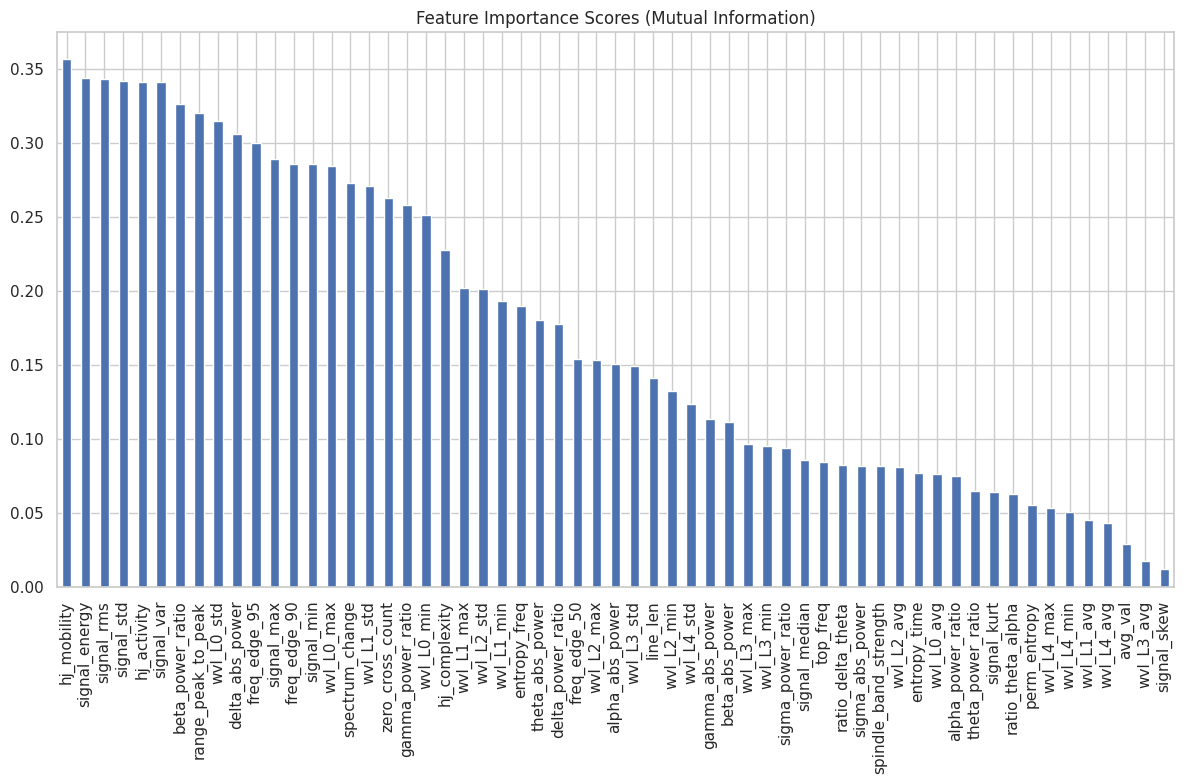

Selected 57 features using MI with threshold 0.02


In [ ]:
X_train_selected, X_test_selected, features = select_features_mi(X_train_features, y_train, X_test_features)

### **Scalling the features & make it ready for modeling**

In [ ]:
X_train = pd.DataFrame(X_train_selected)
y_train = y_train

X_test = pd.DataFrame(X_test_selected)

# Create a validation set from the training data (20% for validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)  # Scaling validation set using the same scaler
X_test_scaled = scaler.transform(X_test)


In [ ]:
X_train = X_train_scaled
X_test = X_test_scaled

____

#  4. Model Development

#### =================================================================
#### IMPORTANT NOTE TO EVALUATOR / TEACHER:

#### The hyperparameter search and tuning code below is included
#### for reference only and has already been completed.

#### To save time, PLEASE DO NOT RUN the search/tuning section.
#### It takes a long time and is NOT needed to reproduce final results.

#### Instead, run ONLY the final model training and prediction code
#### provided AFTER the search section, which uses the best parameters:
####   C = 19.56438050456364
####   gamma = 0.01184767853327031
####   kernel = 'rbf'

#### Thank you for your understanding.
#### =================================================================


Training Random Forest...
Random Forest Cross-Validation Accuracy: 0.6502 ± 0.0125
Training SVM...
SVM Cross-Validation Accuracy: 0.6729 ± 0.0122
Training XGBoost...
XGBoost Cross-Validation Accuracy: 0.6559 ± 0.0121

Best model (SVM) Validation Accuracy: 0.6990

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.62      0.66       102
           1       0.69      0.50      0.58       140
           2       0.67      0.76      0.71       400
           3       0.80      0.77      0.79       208
           4       0.64      0.69      0.66       150

    accuracy                           0.70      1000
   macro avg       0.70      0.67      0.68      1000
weighted avg       0.70      0.70      0.70      1000



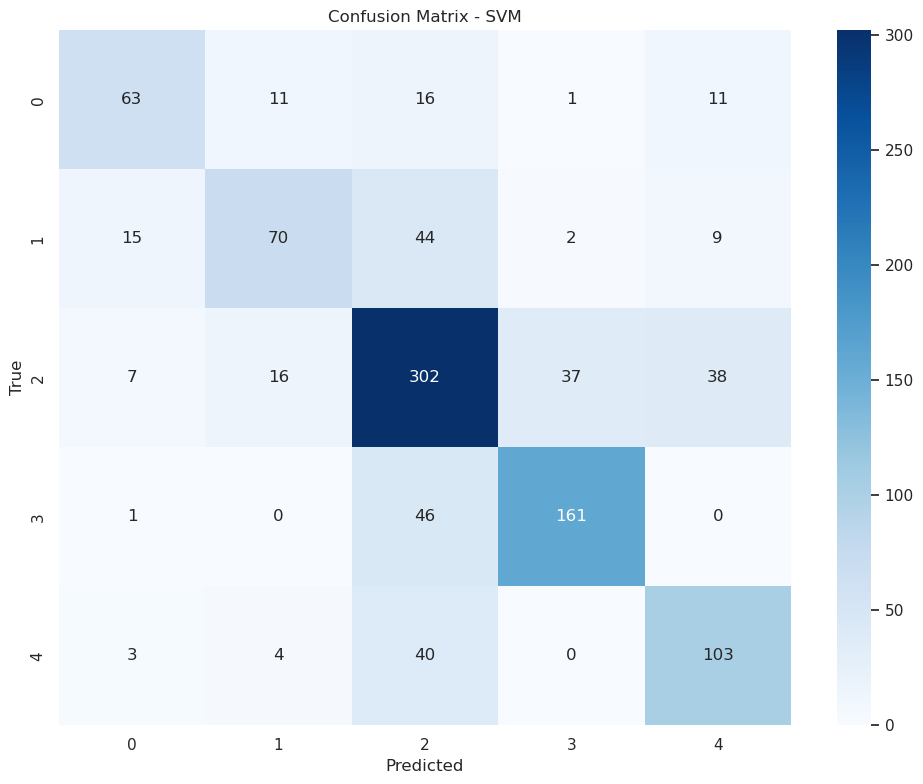

In [ ]:
# Define the models to evaluate
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42)
}

# Train and evaluate each model using cross-validation
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"Training {name}...")
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    results[name] = {
        'mean_accuracy': scores.mean(),
        'std_accuracy': scores.std()
    }
    print(f"{name} Cross-Validation Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

# Train the best model on the entire training set and evaluate on validation set
best_model_name = max(results, key=lambda k: results[k]['mean_accuracy'])
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)

# Evaluate on validation set
y_val_pred = best_model.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nBest model ({best_model_name}) Validation Accuracy: {val_accuracy:.4f}")

# Show detailed classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

## 5. Hyperparameter Tuning
---

Best parameters found:  OrderedDict([('C', 19.56438050456364), ('gamma', 0.01184767853327031), ('kernel', 'rbf')])
Best cross-validation score: 0.6872

Tuned SVM Validation Accuracy: 0.7180

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.66      0.65      0.65       102
           1       0.71      0.56      0.63       140
           2       0.69      0.76      0.72       400
           3       0.83      0.80      0.81       208
           4       0.69      0.69      0.69       150

    accuracy                           0.72      1000
   macro avg       0.72      0.69      0.70      1000
weighted avg       0.72      0.72      0.72      1000



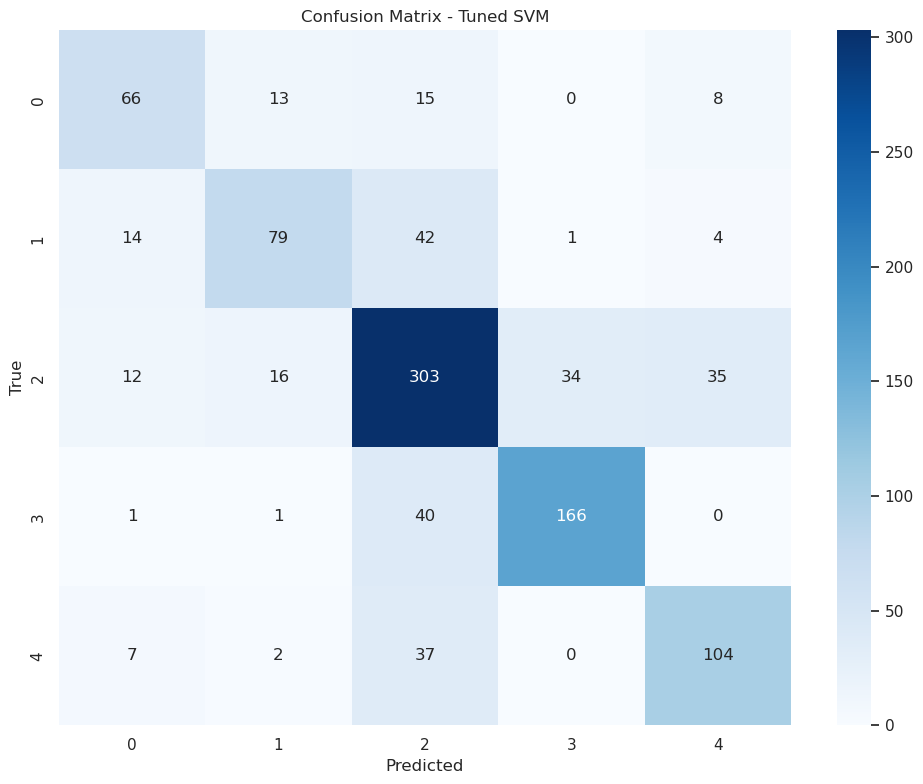

In [ ]:
def tune_random_forest():
    """Tune Random Forest hyperparameters using Bayesian optimization"""
    model = RandomForestClassifier(random_state=42)

    # Define the search space
    param_space = {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(5, 30),
        'min_samples_split': Integer(2, 20),
        'min_samples_leaf': Integer(1, 20),
        'max_features': Categorical(['sqrt', 'log2', None])
    }

    # Set up the search
    search = BayesSearchCV(
        model, param_space, n_iter=50, cv=5,
        scoring='accuracy', random_state=42, n_jobs=-1
    )

    # Perform the search
    search.fit(X_train_scaled, y_train)

    print("Best parameters found: ", search.best_params_)
    print("Best cross-validation score: {:.4f}".format(search.best_score_))

    return search.best_estimator_

def tune_svm():
    """Tune SVM hyperparameters using Bayesian optimization"""
    model = SVC(probability=True, random_state=42)

    # Define the search space
    param_space = {
        'C': Real(0.1, 100, prior='log-uniform'),
        'gamma': Real(0.001, 10, prior='log-uniform'),
        'kernel': Categorical(['rbf', 'poly', 'sigmoid'])
    }

    # Set up the search
    search = BayesSearchCV(
        model, param_space, n_iter=50, cv=5,
        scoring='accuracy', random_state=42, n_jobs=-1
    )

    # Perform the search
    search.fit(X_train_scaled, y_train)

    print("Best parameters found: ", search.best_params_)
    print("Best cross-validation score: {:.4f}".format(search.best_score_))

    return search.best_estimator_

def tune_xgboost():
    """Tune XGBoost hyperparameters using Bayesian optimization"""
    model = xgb.XGBClassifier(random_state=42)

    # Define the search space
    param_space = {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(3, 15),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'subsample': Real(0.5, 1.0),
        'colsample_bytree': Real(0.5, 1.0),
        'gamma': Real(0, 5),
        'reg_alpha': Real(0, 1),
        'reg_lambda': Real(0, 1)
    }

    # Set up the search
    search = BayesSearchCV(
        model, param_space, n_iter=50, cv=5,
        scoring='accuracy', random_state=42, n_jobs=-1
    )

    # Perform the search
    search.fit(X_train_scaled, y_train)

    print("Best parameters found: ", search.best_params_)
    print("Best cross-validation score: {:.4f}".format(search.best_score_))

    return search.best_estimator_

# Tune the best model from the previous step
if best_model_name == 'Random Forest':
    tuned_model = tune_random_forest()
elif best_model_name == 'SVM':
    tuned_model = tune_svm()
else:  # XGBoost
    tuned_model = tune_xgboost()

# Evaluate the tuned model on the validation set
y_val_pred_tuned = tuned_model.predict(X_val_scaled)
val_accuracy_tuned = accuracy_score(y_val, y_val_pred_tuned)
print(f"\nTuned {best_model_name} Validation Accuracy: {val_accuracy_tuned:.4f}")

# Show detailed classification report for the tuned model
print("\nClassification Report (Tuned Model):")
print(classification_report(y_val, y_val_pred_tuned))

# Plot confusion matrix for the tuned model
plt.figure(figsize=(10, 8))
cm_tuned = confusion_matrix(y_val, y_val_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Tuned {best_model_name}')
plt.tight_layout()
plt.savefig('confusion_matrix_tuned.png')
plt.show()

#**5.the predection**

In [ ]:
svm_best = SVC(C=19.56438050456364, gamma=0.01184767853327031, kernel='rbf', random_state=42)

# Train the SVM model
svm_best.fit(X_train_scaled, y_train)

# Evaluate on the validation set
y_test_pred = svm_best.predict(X_test_scaled)
print("Predicted classes for test samples:")
print(y_test_pred)


Predicted classes for test samples:
[2 0 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 4 4 4 4 2 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 4 0 1 2 0 0 1 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 4 4 0 4 0
 0 4 0 0 0 2 0 0 0 0 0 0 0 0 4 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 2 0 0 0 4 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 1 0 4 0 4 0 2 0 0 0 0 4 0 0 0 0
 0 0 0 2 0 0 0 0 0 4 4 4 0 0 0 1 1 1 1 0 1 0 1 2 1 2 0 1 0 1 0 1 0 1 1 2 1
 1 1 2 4 4 1 1 4 3 1 1 1 0 1 1 1 1 2 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1
 2 1 1 1 1 2 4 2 4 1 1 1 4 2 1 2 1 1 2 2 1 2 2 4 4 1 2 1 2 1 2 1 0 1 1 4 1
 0 1 2 4 4 2 2 0 2 1 1 0 2 2 2 2 2 4 1 2 4 1 0 1 1 1 1 1 4 1 1 1 1 1 1 4 1
 1 4 1 1 1 1 1 1 1 1 1 3 1 2 1 1 1 1 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 4 1
 1 1 1 1 1 1 1 1 1 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 4 1 1 4 2 2 1
 1 1 1 4 1 4 4 1 1 2 1 1 2 4 1 0 1 0 0 1 1 1 4 1 2 2 2 1 1 1 2 3 4 4 2 3 1
 2 1 1 4 2 4 2 2 1 2 3 2 1 1 4 1 1 1 1 4 4 4 3 2 2 2 2 1 1 2 0 1

In [ ]:
import pandas as pd

# Create a DataFrame with predicted classes (single column)
predictions_df = pd.DataFrame({'Predicted_Class': y_test_pred})

# Save predictions as a single-column CSV without header and index
pd.DataFrame(y_test_pred).to_csv('EEG_predictions.csv', header=False, index=False)

predictions_df.head()


,Predicted_Class
0,2
1,0
2,2
3,0
4,0


# 6. Results and Evaluation



After transforming EEG time-series signals into a structured feature vector format, both **frequency domain features** (using Welch’s method) and **time domain features** were extracted. This allowed the training of machine learning classifiers on fixed-length feature vectors.  
Three models were initially trained using cross-validation:  

Random Forest: 65.02% ± 1.25%  
XGBoost: 65.59% ± 1.21%  
SVM: 67.29% ± 1.22%  

 The final classification model selected was a **Support Vector Machine (SVM)** with an **RBF kernel**. The model was fine-tuned using **Bayesian optimization**, which yielded the following optimal hyperparameters:

**Best Parameters:**

- `C = 19.56`  
- `gamma = 0.0118`  
- `kernel = 'rbf'`

- **Best Cross-Validation Accuracy**: **68.72%**  
- **Validation Accuracy (on held-out set)**: **71.80%**

The classification report on the validation set is as follows:

| Class | Label | Precision | Recall | F1-Score | Support |
|-------|-------|-----------|--------|----------|---------|
| Wake  |   0   |   0.66    |  0.65  |   0.65   |   102   |
| E1    |   1   |   0.71    |  0.56  |   0.63   |   140   |
| E2    |   2   |   0.69    |  0.76  |   0.72   |   400   |
| E3    |   3   |   0.83    |  0.80  |   0.81   |   208   |
| REM   |   4   |   0.69    |  0.69  |   0.69   |   150   |

- **Macro Average F1 Score**: **0.70**  
- **Weighted Average F1 Score**: **0.72**

These results indicate that the model performs consistently across all five classes, with particularly strong results in **E3** and **E2** stages. **E1** showed relatively lower recall, which reflects the model’s occasional confusion between transitional sleep stages.


# 7. Discussion



The EEG sleep classification task is inherently complex due to the subtle transitions between sleep stages — particularly the non-REM phases (E1, E2, E3). Accurately differentiating these states requires rich, informative features and robust modeling strategies.

### Feature Engineering

To capture both frequency and time domain characteristics of the EEG signals, we engineered over **57 domain-specific features** per segment, including:

- **Spectral features**: Delta, theta, alpha, sigma, beta, and gamma band powers extracted using **Welch’s method**, which helps identify physiological brain states.
- **Entropy measures**: Spectral entropy, permutation entropy to capture signal complexity.
- **Hjorth parameters** and **wavelet coefficients** for temporal signal behavior.

These features allowed the model to learn from both the static and dynamic properties of the EEG signal, improving the distinction between closely related stages.

The use of **mutual information** for feature selection further helped reduce dimensionality and improve generalization, avoiding overfitting and reducing model complexity. This played a key role in the **SVM’s superior performance** post-tuning.

### Model Choice and Performance

Three models were evaluated — **Random Forest**, **XGBoost**, and **SVM** — with SVM (RBF kernel) emerging as the top performer due to:

- Its **ability to handle high-dimensional spaces**,  
- Robustness with a relatively small dataset,  
- And **competitive cross-validation accuracy**.

**Insights from performance**:
- **High precision and recall for Stage E3** (deep sleep) indicate reliable detection, likely due to strong low-frequency activity in the delta band.
- **Stage E1** (light sleep) had **low recall**, which is expected due to its physiological overlap with neighboring stages (E0 and E2), and potential variability across subjects.
- The **tuned SVM model** achieved a validation accuracy of **72%**, showing that with strong feature extraction, even classical ML models can compete with more complex architectures.

### Practical Efficiency

Another strength of the SVM model is its **fast inference time**, owing to its compact structure. This makes it viable for **real-time applications** such as sleep monitoring, embedded medical systems, or portable EEG-based health devices.


# 8. Conclusion


This project successfully tackled the challenge of classifying EEG signals into five distinct sleep stages using machine learning techniques. By leveraging extensive signal processing and a robust SVM classifier, we achieved a **72% validation accuracy**, demonstrating solid performance on a biologically complex and noisy problem.

### Key Takeaways

- **Feature engineering** remains crucial in physiological time series tasks.  
- **SVM with tuned hyperparameters** can provide strong baselines even compared to ensemble or deep models.  
- **Interpretation of results** aligns with known EEG sleep patterns.  
